Accepted 001/100 (global_id=2, difficulty=5.471, w_range=(2.092, 1.793, 1.068), ratio=(1.93, 0.93, 1.25), abl=(1.75, 1.43, 1.31))
Accepted 002/100 (global_id=7, difficulty=8.239, w_range=(3.925, 2.231, 1.564), ratio=(0.97, 0.43, 0.85), abl=(1.30, 1.29, 1.26))
Accepted 003/100 (global_id=10, difficulty=9.984, w_range=(3.923, 3.506, 1.931), ratio=(0.61, 0.42, 0.45), abl=(1.79, 1.22, 1.12))
Accepted 004/100 (global_id=14, difficulty=3.174, w_range=(0.922, 1.151, 0.749), ratio=(3.46, 1.46, 2.25), abl=(0.93, 0.63, 1.18))
Accepted 005/100 (global_id=17, difficulty=5.380, w_range=(1.732, 2.150, 1.101), ratio=(1.10, 1.30, 1.95), abl=(0.89, 0.88, 0.89))
Accepted 006/100 (global_id=20, difficulty=7.034, w_range=(2.595, 2.337, 1.617), ratio=(0.93, 0.86, 1.39), abl=(1.38, 1.22, 0.77))
Accepted 007/100 (global_id=26, difficulty=4.576, w_range=(1.566, 1.749, 0.756), ratio=(1.99, 1.85, 3.78), abl=(1.62, 1.59, 1.13))
Accepted 008/100 (global_id=27, difficulty=6.746, w_range=(2.554, 2.510, 1.236), rati

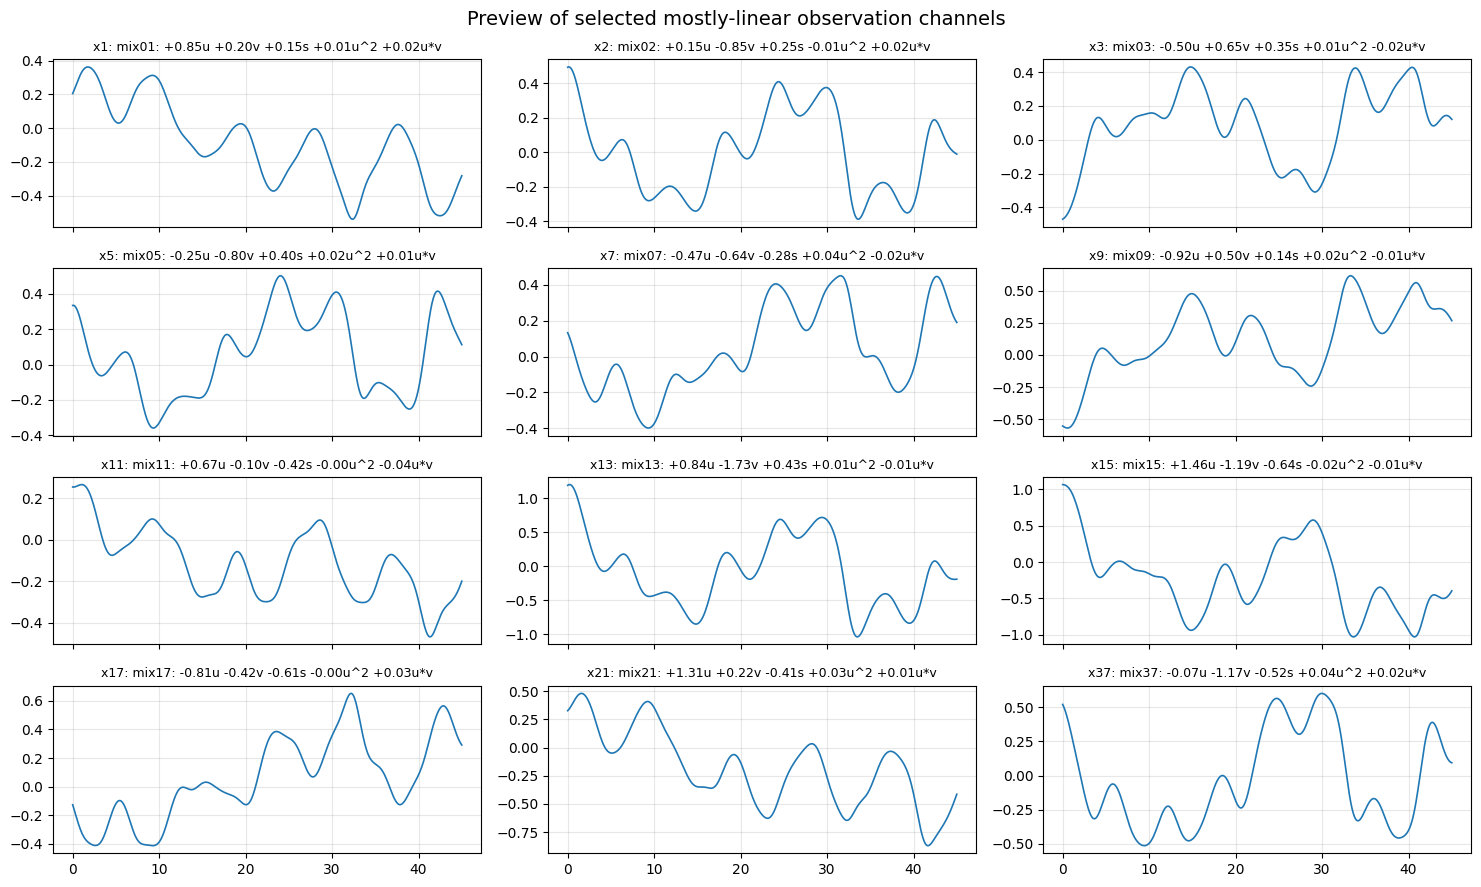

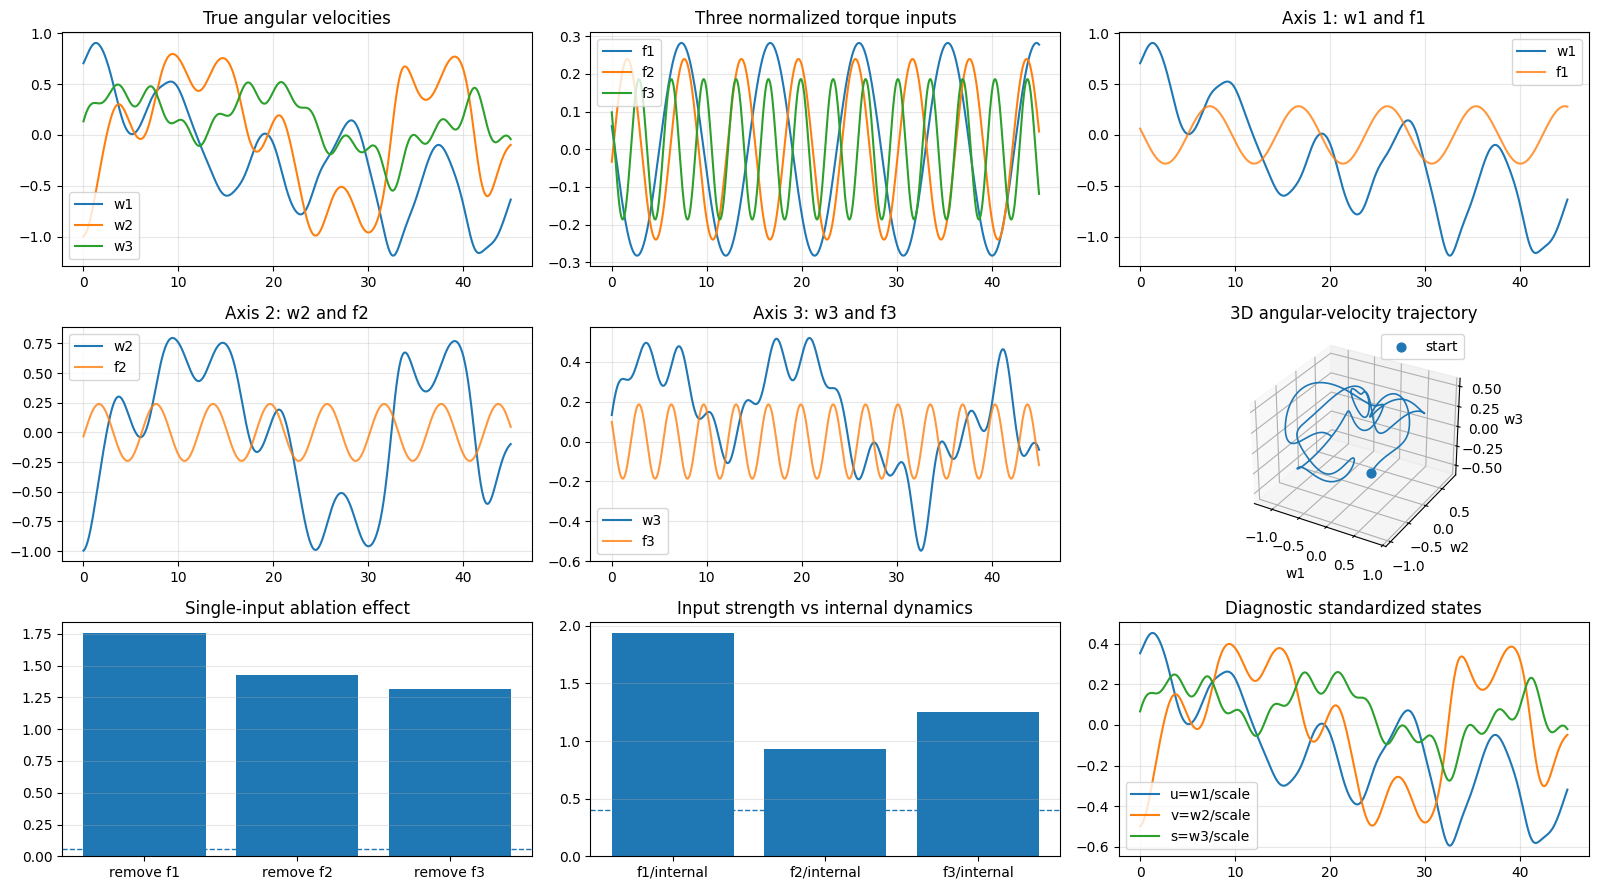

In [5]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ============================================================
# Three-input forced Euler rigid-body dataset
# ============================================================


# ======================
# Basic settings
# ======================
num_train = 80
num_var = 10
num_test = 10
num_total = num_train + num_var + num_test

seq_len = 600
high_dim = 64

root_dir = "rigid_body_euler_three_input_poly_observation"
train_dir = os.path.join(root_dir, "train")
var_dir = os.path.join(root_dir, "var")
test_dir = os.path.join(root_dir, "test")

clear_existing = True
seed = 42
rng = np.random.default_rng(seed)


# ======================
# Time settings
# ======================
t_end = 45.0
T_burn = 0.0
burn_len = 1


# ======================
# Rigid-body parameters
# ======================
I1 = 1.0
I2 = 2.0
I3 = 3.0

a1 = (I2 - I3) / I1      # -1.0
a2 = (I3 - I1) / I2      #  1.0
a3 = (I1 - I2) / I3      # -1/3
damping = 0.0


# ======================
# Three independent harmonic torque inputs
# ======================
A1_range = (0.22, 0.40)
A2_range = (0.22, 0.38)
A3_range = (0.18, 0.34)

Omega1_range = (0.40, 0.75)
Omega2_range = (0.85, 1.25)
Omega3_range = (1.35, 1.85)

phi_range = (0.0, 2.0 * np.pi)

min_forcing_std_allowed = 0.12
max_abs_input_corr_allowed = 0.55

state_limit = 10.0

min_w_range_allowed = 0.45
max_w_range_allowed = 5.0

min_force_internal_ratio = 0.40
min_single_input_ablation_effect = 0.055

max_attempts = 80000


# ======================
# State scaling for polynomial observation
# ======================
# Angular velocity components have the same unit. Use the same scale.
w_center = 0.0
w_scale = 2.0


def standardize_state_for_lift(w1, w2, w3):
    u = (np.asarray(w1, dtype=np.float64) - w_center) / w_scale
    v = (np.asarray(w2, dtype=np.float64) - w_center) / w_scale
    s = (np.asarray(w3, dtype=np.float64) - w_center) / w_scale
    return u, v, s


# ======================
# Polynomial observation settings
# ======================

poly_feature_names = [
    "u", "v", "s",
    "u^2", "u*v", "u*s", "v^2", "v*s", "s^2",
]

num_poly_terms = len(poly_feature_names)

obs_coef = np.zeros((high_dim, num_poly_terms), dtype=np.float64)
obs_bias = np.zeros(high_dim, dtype=np.float64)

for i in range(high_dim):
    # Linear part: dominant
    obs_coef[i, 0:3] = rng.normal(0.0, 1.0, size=3)

    # Quadratic part: deliberately weak
    obs_coef[i, 3:9] = rng.normal(0.0, 0.025, size=6)

    # Avoid nearly zero linear sensitivity.
    if np.linalg.norm(obs_coef[i, 0:3]) < 0.45:
        obs_coef[i, 0:3] += rng.normal(0.0, 0.8, size=3)

manual_mixtures = [
    [0.85, 0.20, 0.15, 0.01, 0.02, -0.01, -0.01, 0.01, 0.01],
    [0.15, -0.85, 0.25, -0.01, 0.02, 0.01, 0.01, -0.01, 0.01],
    [-0.50, 0.65, 0.35, 0.01, -0.02, 0.01, 0.01, 0.01, -0.01],
    [0.90, -0.25, -0.18, 0.01, 0.02, 0.01, 0.01, -0.01, 0.01],
    [-0.25, -0.80, 0.40, 0.02, 0.01, -0.01, -0.01, 0.01, 0.01],
    [0.45, 0.55, -0.30, -0.01, 0.02, 0.01, 0.01, 0.01, -0.01],
]

for i, coef in enumerate(manual_mixtures):
    obs_coef[i, :] = np.asarray(coef, dtype=np.float64)


def build_polynomial_basis(u, v, s):
    return np.stack(
        [
            u,
            v,
            s,
            u ** 2,
            u * v,
            u * s,
            v ** 2,
            v * s,
            s ** 2,
        ],
        axis=0,
    )


def lift_to_high_dim(w1, w2, w3):
    u, v, s = standardize_state_for_lift(w1, w2, w3)
    P = build_polynomial_basis(u, v, s)

    X = obs_bias[:, None] + obs_coef @ P
    X = X.astype(np.float32)

    if X.shape[0] != high_dim:
        raise RuntimeError(f"Expected {high_dim} lifted channels, got {X.shape[0]}.")
    if not np.all(np.isfinite(X)):
        raise RuntimeError("Non-finite values in lifted observations.")

    feature_names = []
    for i in range(high_dim):
        pieces = []
        for ccoef, name in zip(obs_coef[i], poly_feature_names):
            if abs(ccoef) >= 1e-8:
                pieces.append(f"{ccoef:+.2f}{name}")
        feature_names.append(f"mix{i + 1:02d}: " + " ".join(pieces))

    return X, feature_names


# ======================
# Forcing functions
# ======================
def eval_f_all(t, params, zero_index=None):
    t_arr = np.asarray(t, dtype=np.float64)

    f1 = params["A1"] * np.sin(params["Omega1"] * t_arr + params["phi1"])
    f2 = params["A2"] * np.sin(params["Omega2"] * t_arr + params["phi2"])
    f3 = params["A3"] * np.sin(params["Omega3"] * t_arr + params["phi3"])

    if zero_index == 0:
        f1 = np.zeros_like(t_arr)
    elif zero_index == 1:
        f2 = np.zeros_like(t_arr)
    elif zero_index == 2:
        f3 = np.zeros_like(t_arr)

    if np.isscalar(t):
        return float(f1), float(f2), float(f3)

    return f1, f2, f3


def sample_forcing_params():
    return {
        "A1": float(rng.uniform(*A1_range)),
        "A2": float(rng.uniform(*A2_range)),
        "A3": float(rng.uniform(*A3_range)),
        "Omega1": float(rng.uniform(*Omega1_range)),
        "Omega2": float(rng.uniform(*Omega2_range)),
        "Omega3": float(rng.uniform(*Omega3_range)),
        "phi1": float(rng.uniform(*phi_range)),
        "phi2": float(rng.uniform(*phi_range)),
        "phi3": float(rng.uniform(*phi_range)),
    }


def input_correlation_ok(f_mat):
    corr = np.corrcoef(f_mat.T)
    offdiag = corr[np.triu_indices(3, k=1)]
    return np.all(np.abs(offdiag) <= max_abs_input_corr_allowed), corr


# ======================
# Forced Euler rigid-body equations
# ======================
def rigid_body_three_input(t, state, forcing_params, zero_index=None):
    w1, w2, w3 = state

    if not np.isfinite(w1) or not np.isfinite(w2) or not np.isfinite(w3):
        return [0.0, 0.0, 0.0]

    f1, f2, f3 = eval_f_all(t, forcing_params, zero_index=zero_index)

    dw1 = a1 * w2 * w3 - damping * w1 + f1
    dw2 = a2 * w3 * w1 - damping * w2 + f2
    dw3 = a3 * w1 * w2 - damping * w3 + f3

    return [dw1, dw2, dw3]


def make_stop_event():
    def stop_if_invalid(t, state):
        w1, w2, w3 = state
        return min(
            state_limit - abs(w1),
            state_limit - abs(w2),
            state_limit - abs(w3),
        )

    stop_if_invalid.terminal = True
    stop_if_invalid.direction = -1
    return stop_if_invalid


def is_valid_solution(sol, expected_len):
    if not sol.success:
        return False
    if sol.y.shape[1] != expected_len:
        return False

    w1 = sol.y[0]
    w2 = sol.y[1]
    w3 = sol.y[2]

    if not np.all(np.isfinite(w1)) or not np.all(np.isfinite(w2)) or not np.all(np.isfinite(w3)):
        return False
    if np.max(np.abs(w1)) > state_limit or np.max(np.abs(w2)) > state_limit or np.max(np.abs(w3)) > state_limit:
        return False

    return True


def normalized_rms_difference(full_y, ablated_y):
    # Shape [3, T]
    scale = np.sqrt(np.mean(full_y ** 2)) + 1e-12
    return float(np.sqrt(np.mean((full_y - ablated_y) ** 2)) / scale)


# ======================
# One sample simulation
# ======================
def simulate_one_candidate(global_id):
    forcing_params = sample_forcing_params()

    # Random initial angular velocity. Keep it moderate so forcing is not hidden
    # behind very large internal quadratic terms.
    y0 = rng.uniform(-1.20, 1.20, size=3).astype(np.float64)

    if np.linalg.norm(y0) < 0.45:
        y0 += rng.normal(0.0, 0.30, size=3)

    # Formal segment
    t = np.linspace(0.0, t_end, seq_len, dtype=np.float64)
    f1, f2, f3 = eval_f_all(t, forcing_params)
    f_mat = np.stack([f1, f2, f3], axis=1)

    if np.min(np.std(f_mat, axis=0)) < min_forcing_std_allowed:
        raise RuntimeError("Rejected: one forcing channel too weak")

    corr_ok, input_corr = input_correlation_ok(f_mat)
    if not corr_ok:
        raise RuntimeError("Rejected: input channels too correlated")

    stop_event = make_stop_event()

    sol = solve_ivp(
        fun=lambda tt, yy: rigid_body_three_input(tt, yy, forcing_params),
        t_span=(t[0], t[-1]),
        y0=y0,
        t_eval=t,
        method="DOP853",
        rtol=1e-8,
        atol=1e-10,
        events=stop_event,
        max_step=0.035,
    )

    if not is_valid_solution(sol, seq_len):
        raise RuntimeError(f"Invalid formal solution at global_id={global_id}")

    w1 = sol.y[0].astype(np.float64)
    w2 = sol.y[1].astype(np.float64)
    w3 = sol.y[2].astype(np.float64)

    w1_range = float(np.max(w1) - np.min(w1))
    w2_range = float(np.max(w2) - np.min(w2))
    w3_range = float(np.max(w3) - np.min(w3))

    if min(w1_range, w2_range, w3_range) < min_w_range_allowed:
        raise RuntimeError("Rejected: one angular velocity range too small")
    if max(w1_range, w2_range, w3_range) > max_w_range_allowed:
        raise RuntimeError("Rejected: one angular velocity range too large")

    # Ensure each input is not tiny compared with the corresponding internal nonlinear torque.
    internal1 = a1 * w2 * w3
    internal2 = a2 * w3 * w1
    internal3 = a3 * w1 * w2

    ratios = np.array([
        np.std(f1) / (np.std(internal1) + 1e-12),
        np.std(f2) / (np.std(internal2) + 1e-12),
        np.std(f3) / (np.std(internal3) + 1e-12),
    ])

    if np.min(ratios) < min_force_internal_ratio:
        raise RuntimeError("Rejected: one forcing channel is too weak relative to internal dynamics")

    # Ablation checks: remove each input individually and require noticeable trajectory change.
    ablation_effects = []
    for zero_idx in range(3):
        sol_ab = solve_ivp(
            fun=lambda tt, yy: rigid_body_three_input(tt, yy, forcing_params, zero_index=zero_idx),
            t_span=(t[0], t[-1]),
            y0=y0,
            t_eval=t,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            events=make_stop_event(),
            max_step=0.035,
        )
        if not is_valid_solution(sol_ab, seq_len):
            raise RuntimeError("Rejected: ablation solution invalid")
        effect = normalized_rms_difference(sol.y, sol_ab.y)
        ablation_effects.append(effect)

    ablation_effects = np.asarray(ablation_effects, dtype=np.float64)

    if np.min(ablation_effects) < min_single_input_ablation_effect:
        raise RuntimeError("Rejected: one forcing channel has negligible ablation effect")

    u, v, s = standardize_state_for_lift(w1, w2, w3)
    X_high, feature_names = lift_to_high_dim(w1, w2, w3)

    sample = {
        "t": t.astype(np.float32),
        "f": f_mat.astype(np.float32),
        "f1": f1.astype(np.float32),
        "f2": f2.astype(np.float32),
        "f3": f3.astype(np.float32),
        "w1_true": w1.astype(np.float32),
        "w2_true": w2.astype(np.float32),
        "w3_true": w3.astype(np.float32),
        "u_true": u.astype(np.float32),
        "v_true": v.astype(np.float32),
        "s_true": s.astype(np.float32),
    }

    for i in range(high_dim):
        sample[f"x{i + 1}"] = X_high[i].astype(np.float32)

    dw1 = np.gradient(w1, t)
    dw2 = np.gradient(w2, t)
    dw3 = np.gradient(w3, t)

    difficulty = (
        w1_range + w2_range + w3_range
        + 0.15 * float(np.std(dw1))
        + 0.15 * float(np.std(dw2))
        + 0.15 * float(np.std(dw3))
        + 0.25 * float(np.mean(np.std(f_mat, axis=0)))
        + 0.25 * float(np.mean(ablation_effects))
    )

    metadata = {
        "global_id": global_id,
        **forcing_params,
        "w1_0_formal": float(y0[0]),
        "w2_0_formal": float(y0[1]),
        "w3_0_formal": float(y0[2]),
        "w1_min": float(np.min(w1)),
        "w1_max": float(np.max(w1)),
        "w2_min": float(np.min(w2)),
        "w2_max": float(np.max(w2)),
        "w3_min": float(np.min(w3)),
        "w3_max": float(np.max(w3)),
        "w1_range": w1_range,
        "w2_range": w2_range,
        "w3_range": w3_range,
        "dw1_std": float(np.std(dw1)),
        "dw2_std": float(np.std(dw2)),
        "dw3_std": float(np.std(dw3)),
        "f1_std": float(np.std(f1)),
        "f2_std": float(np.std(f2)),
        "f3_std": float(np.std(f3)),
        "f1_min": float(np.min(f1)),
        "f1_max": float(np.max(f1)),
        "f2_min": float(np.min(f2)),
        "f2_max": float(np.max(f2)),
        "f3_min": float(np.min(f3)),
        "f3_max": float(np.max(f3)),
        "input_corr_12": float(input_corr[0, 1]),
        "input_corr_13": float(input_corr[0, 2]),
        "input_corr_23": float(input_corr[1, 2]),
        "force_internal_ratio_1": float(ratios[0]),
        "force_internal_ratio_2": float(ratios[1]),
        "force_internal_ratio_3": float(ratios[2]),
        "ablation_effect_f1": float(ablation_effects[0]),
        "ablation_effect_f2": float(ablation_effects[1]),
        "ablation_effect_f3": float(ablation_effects[2]),
        "difficulty": float(difficulty),
    }

    return sample, metadata, feature_names


# ======================
# Prepare folders
# ======================
if clear_existing and os.path.exists(root_dir):
    shutil.rmtree(root_dir)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(var_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


# ======================
# Generate samples
# ======================
samples = []
metadata_list = []
feature_names_global = None

attempt = 0
global_id = 1

while len(samples) < num_total and attempt < max_attempts:
    attempt += 1

    try:
        sample, metadata, feature_names = simulate_one_candidate(global_id)
    except RuntimeError:
        global_id += 1
        continue

    samples.append(sample)
    metadata_list.append(metadata)
    if feature_names_global is None:
        feature_names_global = list(feature_names)

    print(
        f"Accepted {len(samples):03d}/{num_total} "
        f"(global_id={global_id}, "
        f"difficulty={metadata['difficulty']:.3f}, "
        f"w_range=({metadata['w1_range']:.3f}, {metadata['w2_range']:.3f}, {metadata['w3_range']:.3f}), "
        f"ratio=({metadata['force_internal_ratio_1']:.2f}, {metadata['force_internal_ratio_2']:.2f}, {metadata['force_internal_ratio_3']:.2f}), "
        f"abl=({metadata['ablation_effect_f1']:.2f}, {metadata['ablation_effect_f2']:.2f}, {metadata['ablation_effect_f3']:.2f})"
        f")"
    )

    global_id += 1

if len(samples) < num_total:
    raise RuntimeError(
        f"Only generated {len(samples)}/{num_total} samples after {attempt} attempts."
    )

print(f"\nAccepted {len(samples)} samples after {attempt} attempts.")


# ======================
# Stratified split by difficulty
# ======================
order = np.argsort([m["difficulty"] for m in metadata_list])
blocks = [order[i:i + 10] for i in range(0, len(order), 10)]

split_assignments = {}

for block in blocks:
    block = np.asarray(block, dtype=int)
    rng.shuffle(block)

    test_idx = block[0:1]
    var_idx = block[1:2]
    train_idx = block[2:]

    for idx in train_idx:
        split_assignments[int(idx)] = "train"
    for idx in var_idx:
        split_assignments[int(idx)] = "var"
    for idx in test_idx:
        split_assignments[int(idx)] = "test"

split_counts = {
    "train": sum(1 for v in split_assignments.values() if v == "train"),
    "var": sum(1 for v in split_assignments.values() if v == "var"),
    "test": sum(1 for v in split_assignments.values() if v == "test"),
}

expected_counts = {
    "train": num_train,
    "var": num_var,
    "test": num_test,
}

if split_counts != expected_counts:
    raise RuntimeError(f"Unexpected split counts: {split_counts}, expected {expected_counts}")


# ======================
# Save .npy files and metadata
# ======================
local_counter = {"train": 1, "var": 1, "test": 1}
metadata_rows = []

for idx, sample in enumerate(samples):
    split = split_assignments[idx]
    local_id = local_counter[split]
    local_counter[split] += 1

    if split == "train":
        save_folder = train_dir
    elif split == "var":
        save_folder = var_dir
    elif split == "test":
        save_folder = test_dir
    else:
        raise ValueError(split)

    filename = f"rigid_body_3input_{local_id:03d}.npy"
    save_path = os.path.join(save_folder, filename)
    np.save(save_path, sample)

    row = dict(metadata_list[idx])
    row["split"] = split
    row["local_id"] = local_id
    row["filename"] = filename
    metadata_rows.append(row)

metadata_df = pd.DataFrame(metadata_rows)
metadata_csv = os.path.join(root_dir, "metadata.csv")
metadata_df.to_csv(metadata_csv, index=False)


# ======================
# Save generation parameters
# ======================
np.savez(
    os.path.join(root_dir, "generation_params.npz"),
    high_dim=np.asarray([high_dim], dtype=np.int64),
    I1=np.asarray([I1], dtype=np.float32),
    I2=np.asarray([I2], dtype=np.float32),
    I3=np.asarray([I3], dtype=np.float32),
    a1=np.asarray([a1], dtype=np.float32),
    a2=np.asarray([a2], dtype=np.float32),
    a3=np.asarray([a3], dtype=np.float32),
    damping=np.asarray([damping], dtype=np.float32),
    w_center=np.asarray([w_center], dtype=np.float32),
    w_scale=np.asarray([w_scale], dtype=np.float32),
    T_burn=np.asarray([T_burn], dtype=np.float32),
    feature_names=np.asarray(feature_names_global, dtype=object),
    poly_feature_names=np.asarray(poly_feature_names, dtype=object),
    obs_coef=obs_coef.astype(np.float32),
    obs_bias=obs_bias.astype(np.float32),
)

print("\nDone.")
print(f"Dataset folder: {os.path.abspath(root_dir)}")
print(f"Split counts: {split_counts}")
print(f"Metadata: {metadata_csv}")
print(f"Euler coefficients: a1={a1:.6f}, a2={a2:.6f}, a3={a3:.6f}, damping={damping:.6f}")


# ======================
# Diagnostics and preview plots
# ======================
def stack_observations(sample):
    return np.stack([sample[f"x{i + 1}"] for i in range(high_dim)], axis=1)  # [T,64]


def pca_diagnostics_from_samples(samples_for_diag, max_samples=None):
    X_list = []
    use_samples = samples_for_diag if max_samples is None else samples_for_diag[:max_samples]
    for s_item in use_samples:
        X_list.append(stack_observations(s_item))
    X = np.concatenate(X_list, axis=0).astype(np.float64)
    Xc = X - X.mean(axis=0, keepdims=True)
    std = Xc.std(axis=0, keepdims=True)
    std = np.where(std > 1e-12, std, 1.0)
    Xn = Xc / std
    _, sing, _ = np.linalg.svd(Xn, full_matrices=False)
    eig = sing ** 2 / max(Xn.shape[0] - 1, 1)
    ratio = eig / np.sum(eig)
    return ratio


pca_ratio = pca_diagnostics_from_samples(samples, max_samples=30)
print("\nPCA diagnostic on lifted observations:")
print(f"  PC1 ratio       = {pca_ratio[0]:.4f}")
print(f"  PC1+PC2 ratio   = {np.sum(pca_ratio[:2]):.4f}")
print(f"  PC1+...+PC3     = {np.sum(pca_ratio[:3]):.4f}")
print(f"  PC1+...+PC5     = {np.sum(pca_ratio[:5]):.4f}")

# Show one preview sample. You can change preview_idx.
preview_idx = 0
preview = samples[preview_idx]
t = preview["t"]
X_preview = stack_observations(preview)

selected_dims = [1, 2, 3, 5, 7, 9, 11, 13, 15, 17, 21, 37]
selected_dims = [d for d in selected_dims if 1 <= d <= high_dim]

fig, axes = plt.subplots(4, 3, figsize=(15, 9), sharex=True)
axes = axes.ravel()
for ax, d in zip(axes, selected_dims):
    ax.plot(t, X_preview[:, d - 1], linewidth=1.2)
    fname = feature_names_global[d - 1] if feature_names_global is not None else f"x{d}"
    ax.set_title(f"x{d}: {fname[:45]}", fontsize=9)
    ax.grid(True, alpha=0.3)
for ax in axes[len(selected_dims):]:
    ax.axis("off")
fig.suptitle("Preview of selected mostly-linear observation channels", fontsize=14)
fig.tight_layout()
plt.show()

fig = plt.figure(figsize=(16, 9))

ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(t, preview["w1_true"], label="w1")
ax1.plot(t, preview["w2_true"], label="w2")
ax1.plot(t, preview["w3_true"], label="w3")
ax1.set_title("True angular velocities")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(t, preview["f1"], label="f1")
ax2.plot(t, preview["f2"], label="f2")
ax2.plot(t, preview["f3"], label="f3")
ax2.set_title("Three normalized torque inputs")
ax2.grid(True, alpha=0.3)
ax2.legend()

ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(t, preview["w1_true"], label="w1")
ax3.plot(t, preview["f1"], label="f1", alpha=0.8)
ax3.set_title("Axis 1: w1 and f1")
ax3.grid(True, alpha=0.3)
ax3.legend()

ax4 = fig.add_subplot(3, 3, 4)
ax4.plot(t, preview["w2_true"], label="w2")
ax4.plot(t, preview["f2"], label="f2", alpha=0.8)
ax4.set_title("Axis 2: w2 and f2")
ax4.grid(True, alpha=0.3)
ax4.legend()

ax5 = fig.add_subplot(3, 3, 5)
ax5.plot(t, preview["w3_true"], label="w3")
ax5.plot(t, preview["f3"], label="f3", alpha=0.8)
ax5.set_title("Axis 3: w3 and f3")
ax5.grid(True, alpha=0.3)
ax5.legend()

ax6 = fig.add_subplot(3, 3, 6, projection="3d")
ax6.plot(
    preview["w1_true"],
    preview["w2_true"],
    preview["w3_true"],
    linewidth=1.2,
)
ax6.scatter(
    preview["w1_true"][0],
    preview["w2_true"][0],
    preview["w3_true"][0],
    s=40,
    label="start",
)
ax6.set_xlabel("w1")
ax6.set_ylabel("w2")
ax6.set_zlabel("w3")
ax6.set_title("3D angular-velocity trajectory")
ax6.legend()

ax7 = fig.add_subplot(3, 3, 7)
metadata_preview = metadata_list[preview_idx]
bars = [
    metadata_preview["ablation_effect_f1"],
    metadata_preview["ablation_effect_f2"],
    metadata_preview["ablation_effect_f3"],
]
ax7.bar(["remove f1", "remove f2", "remove f3"], bars)
ax7.axhline(min_single_input_ablation_effect, linestyle="--", linewidth=1.0)
ax7.set_title("Single-input ablation effect")
ax7.grid(True, axis="y", alpha=0.3)

ax8 = fig.add_subplot(3, 3, 8)
ratios = [
    metadata_preview["force_internal_ratio_1"],
    metadata_preview["force_internal_ratio_2"],
    metadata_preview["force_internal_ratio_3"],
]
ax8.bar(["f1/internal", "f2/internal", "f3/internal"], ratios)
ax8.axhline(min_force_internal_ratio, linestyle="--", linewidth=1.0)
ax8.set_title("Input strength vs internal dynamics")
ax8.grid(True, axis="y", alpha=0.3)

ax9 = fig.add_subplot(3, 3, 9)
ax9.plot(t, preview["u_true"], label="u=w1/scale")
ax9.plot(t, preview["v_true"], label="v=w2/scale")
ax9.plot(t, preview["s_true"], label="s=w3/scale")
ax9.set_title("Diagnostic standardized states")
ax9.grid(True, alpha=0.3)
ax9.legend()

fig.tight_layout()
plt.show()
